In [1]:
# [설정] 작업 경로를 프로젝트 루트(ess-battery-project)로 맞춘다.
# notebooks/ 안에서 열어도 이후 모든 경로(results/, reports/ ...)가 루트 기준으로 동작한다.
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src" / "features.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("ess-battery-project 루트를 찾지 못했습니다. 노트북을 프로젝트 안에서 여세요.")
    ROOT = ROOT.parent
os.chdir(ROOT)
for p in (ROOT / "src", ROOT / "src" / "eda"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import json

import numpy as np
import pandas as pd
from IPython.display import Image, display
from scipy import stats

from data import cell_table, delta_q, load_all   # src/data.py — 공통 로더
import q2_degradation as q2                      # src/eda — DAY 1 Q2 함수 (불러 쓰기만 하고 파일은 쓰지 않음)
import q5_correlation as q5                      # src/eda — DAY 1 Q5 피처 이름표

pd.set_option("display.max_colwidth", 200)
FIG = ROOT / "reports" / "figures"               # DAY 1 슬라이드 그림
EDA = ROOT / "results" / "eda"                   # DAY 1 EDA 수치 (json)


def show(name, width=760):
    display(Image(filename=str(FIG / name), width=width))


print("작업 경로: 프로젝트 루트", Path.cwd().name)

작업 경로: 프로젝트 루트 ess-battery-project


# 01. EDA — 초기 100 사이클에 수명 신호가 있는가?

**이 노트북의 목적**
- 노션 DAY 1의 EDA 질문 5개에 차례로 답한다.
- 각 답이 DAY 2 모델 설계(타깃·피처·검증 방식)로 어떻게 이어지는지 보여준다.

**읽는 방법**
- 질문마다 **질문 → 방법 → 결과 → 해석·시사점** 순서로 읽으면 된다.
- 그림은 DAY 1 슬라이드 그림(`reports/figures/slide_q*.png`)을 그대로 쓴다.
- 핵심 수치는 이 노트북에서 `src/` 함수로 다시 계산한다. DAY 1 보고서(`reports/day1_design_report.md`)의 값과 같다.
- 상관은 인과가 아니다. 이 노트북에서 '관련 있다'는 '함께 움직인다'는 뜻이다.

**용어**
- **수명(cycle_life)**: 방전 용량이 EOL(정격 용량의 80%, 0.88 Ah) 아래로 처음 떨어지는 사이클.
- **라벨 셀**: EOL까지 기록되어 수명을 아는 셀. Batch 1의 나머지 10셀은 기록이 먼저 끝난 **중도절단** 셀이다.
- **배치 역할**: Batch 1 = 학습, Batch 2 = 테스트(1회), Batch 3 = 추가 검증(선택).

In [2]:
cells = load_all()                      # data/processed/batch{1,2,3}.pkl (src/preprocess.py 산출물)
by_key = {c["cell_key"]: c for c in cells}
T = cell_table(cells)                   # 셀 1개 = 1행: 배치·충전 정책·수명·라벨 여부
LAB = T[T["labeled"]].copy()            # 수명 라벨이 있는 셀만

overview = T.groupby("batch").agg(전체_셀=("cell_key", "size"), 라벨_셀=("labeled", "sum"), 중도절단=("censored", "sum"))
overview["셀 구성"] = T.groupby("batch")["group"].agg(lambda s: " · ".join(f"{k} {v}" for k, v in s.value_counts().items()))
overview

,전체_셀,라벨_셀,중도절단,셀 구성
batch,,,,
batch1,46,36,10,fastcharge 46
batch2,47,39,0,fastcharge 30 · newstructure 9 · varcharge 4 · slowcycle 4
batch3,46,44,0,newstructure 46


- Batch 2의 varcharge·slowcycle 8셀은 수명 라벨이 없어 지도학습과 평가에서 뺀다.
- 이후 분석은 라벨 셀만 기준으로 한다(위 표의 '라벨_셀' 열).

---
## Q1. Cycle Life 분포는 어떻게 생겼는가?

**질문**
- 수명은 어떤 범위에, 어떤 모양으로 퍼져 있는가?
- 장수명(>1,000)과 단수명(<500)은 얼마나 되는가?
- 유독 짧은 셀은 오류인가, 정상적인 꼬리인가?

**방법**
- 라벨 셀만 배치별로 요약한다. 중도절단 셀은 수명의 '하한값'만 알기 때문에 따로 둔다.
- 노션 기준(>1,000 / <500)과 분류 라벨 기준(550)으로 셀 수를 센다.
- log10 변환 전후의 왜도(치우침)를 비교한다.

,라벨 셀,최소,중앙값,최대,단수명 <500,550 미만,"장수명 >1,000",왜도 (원값),왜도 (log10)
배치,,,,,,,,,
batch1,36,534,772.5,1074,0,1,5,0.30,-0.01
batch2,39,392,472.0,1186,28,30,3,1.64,1.36
batch3,44,541,1005.5,1935,0,1,23,1.26,0.52


Batch 2 fastcharge: 30셀, 수명 392~514
Batch 2 newstructure: 9셀, 수명 777~1186


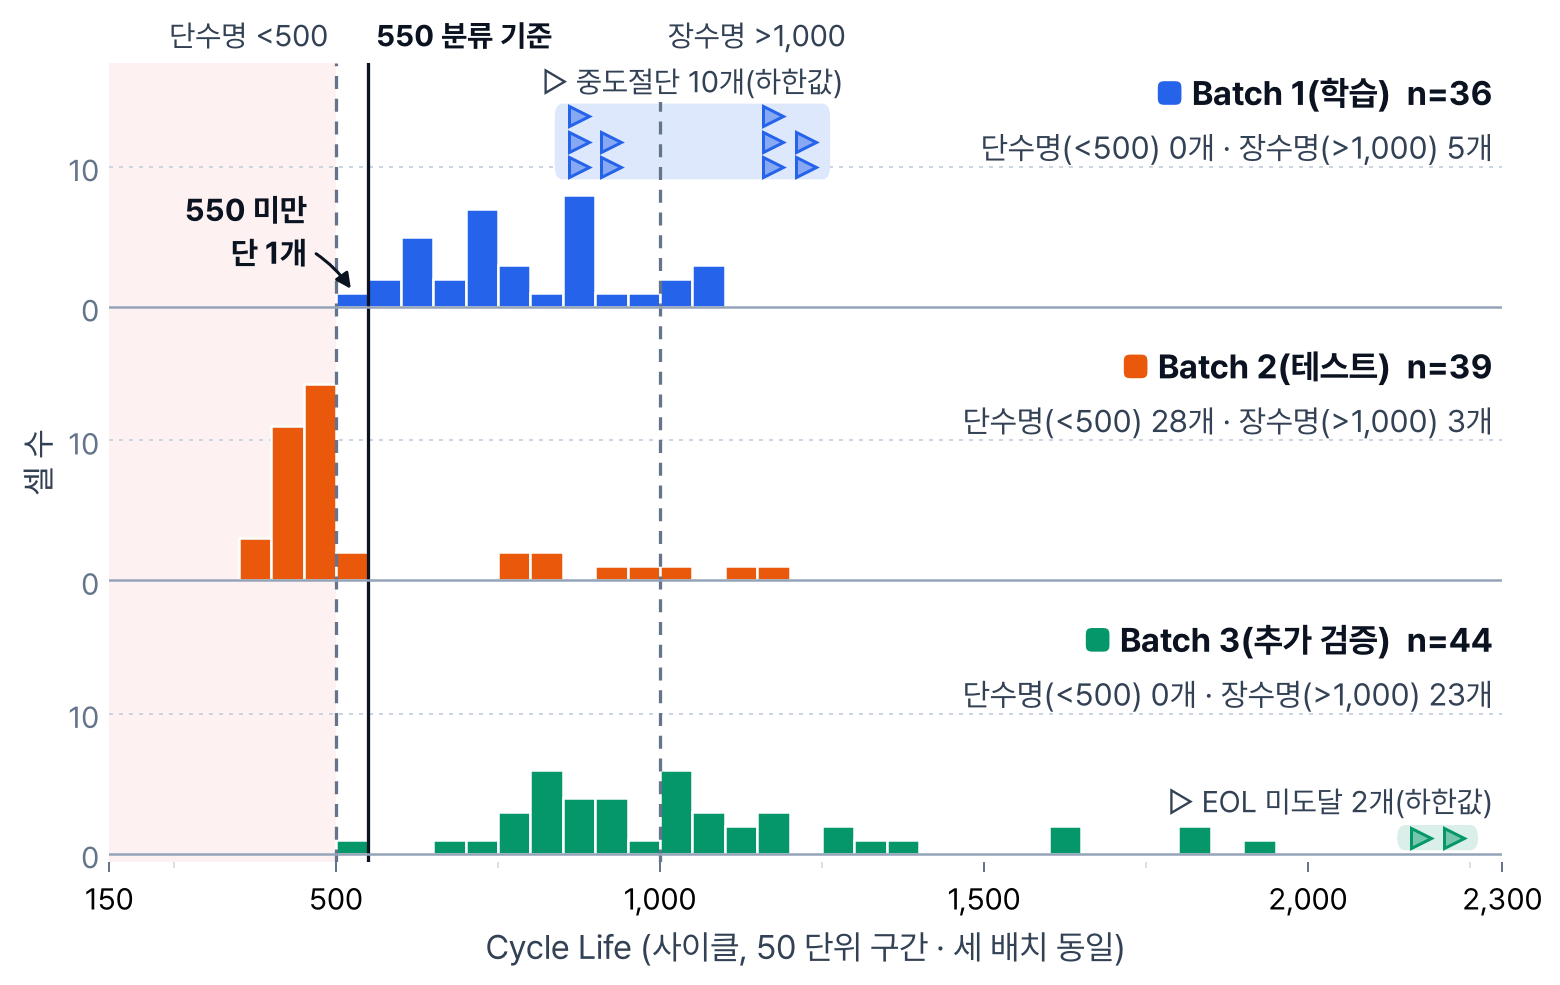

In [3]:
rows = []
for batch, g in LAB.groupby("batch"):
    life = g["cycle_life"]
    rows.append({"배치": batch, "라벨 셀": len(life), "최소": int(life.min()), "중앙값": life.median(),
                 "최대": int(life.max()), "단수명 <500": int((life < 500).sum()), "550 미만": int((life < 550).sum()),
                 "장수명 >1,000": int((life > 1000).sum()),
                 "왜도 (원값)": round(stats.skew(life, bias=False), 2),
                 "왜도 (log10)": round(stats.skew(np.log10(life), bias=False), 2)})
display(pd.DataFrame(rows).set_index("배치"))

b2 = LAB[LAB["batch"] == "batch2"].groupby("group")["cycle_life"].agg(["size", "min", "max"])
for grp, r in b2.iterrows():
    print(f"Batch 2 {grp}: {int(r['size'])}셀, 수명 {int(r['min'])}~{int(r['max'])}")
show("slide_q1.png")

**결과**
- Batch 1(학습)은 534\~1,074 사이의 한 덩어리다.
- 분류 기준(550) 아래 셀은 Batch 1에 하나뿐이다.
- Batch 2(테스트)는 두 덩어리로 갈린다. 고속충전(fastcharge) 셀은 모두 짧고, newstructure 셀은 모두 길다.
- Batch 3(추가 검증)는 오른쪽 꼬리가 길다. 절반 이상이 장수명(>1,000)이다.
- log10으로 바꾸면 Batch 1의 치우침이 거의 0이 된다(표의 왜도 열).

**해석·시사점**
- 학습 배치에 단수명 셀이 사실상 없다. 장/단수명 경계를 배울 수 없으므로 **회귀(Regression)** 를 택한다.
- 수명 차이는 '몇 배' 단위로 나타난다. 모델 안에서는 **log10(cycle_life)** 를 학습하고, 평가는 원래 단위의 MAPE로 한다.
- 학습 배치 안에서도 이미 외삽이 필요하다. Batch 1 중도절단 장수명 5셀(#00\~04)은 학습 라벨과 ΔQ 깊이 범위 밖에 있다 → 범위 밖으로도 예측이 이어지는 **선형 계열 모델**을 우선한다.
- 테스트 배치의 수명 범위가 다르다는 점은 위험으로만 기록했다(설계 근거 아님).
- 짧은 셀은 측정 오류가 아니라 특정 충전 정책에서 이어지는 꼬리였다(DAY 1 보고서 §2). 그래서 지우지 않는다.

<details><summary>참고: 중도절단 셀의 영향 (펼치기)</summary>

- Batch 1 중도절단 10셀을 하한값으로 반영한 Kaplan–Meier 중앙값은 860이다.
- 라벨 셀만 본 중앙값(772.5)보다 길다. 학습 라벨이 실제보다 약간 짧은 쪽으로 치우쳐 있다는 뜻이다.
- 이 셀들은 타깃에서 빼고, '하한보다 길게 예측하는지' 보는 외삽 점검(03 노트북의 게이트)에 쓴다.
</details>

---
## Q2. 열화 곡선 — 방전 용량은 어떻게 줄어드는가?

**질문**
- 용량은 일정한 속도로 줄어드는가, 어느 순간 빨라지는가?
- 급락이 시작되는 지점(knee)은 언제인가? 첫 100 사이클 안에 보이는가?

**방법**
- `src/eda/q2_degradation.py`의 함수를 그대로 불러 쓴다.
  - `qd_series`: 측정 오류를 지운 방전 용량을 9-사이클 이동중앙값으로 부드럽게 만든다.
  - `bacon_watts_knee`: 곡선을 두 직선으로 나눴을 때 오차가 가장 작은 꺾임점을 knee로 본다.
- 첫 100 사이클 동안 줄어든 용량이 전체 손실의 몇 %인지 함께 본다.

,셀,knee 중앙값,knee 최소,knee/수명 (중앙값),첫 100 사이클 손실 비중 % (중앙값),cycle 10→100 용량이 늘어난 셀
batch,,,,,,
batch1,36,577.5,413.0,0.75,0.64,6
batch2,39,341.0,246.0,0.75,-0.19,22
batch3,44,819.5,377.0,0.79,0.59,5


knee가 첫 100 사이클 안에 있는 셀: 0 / 119


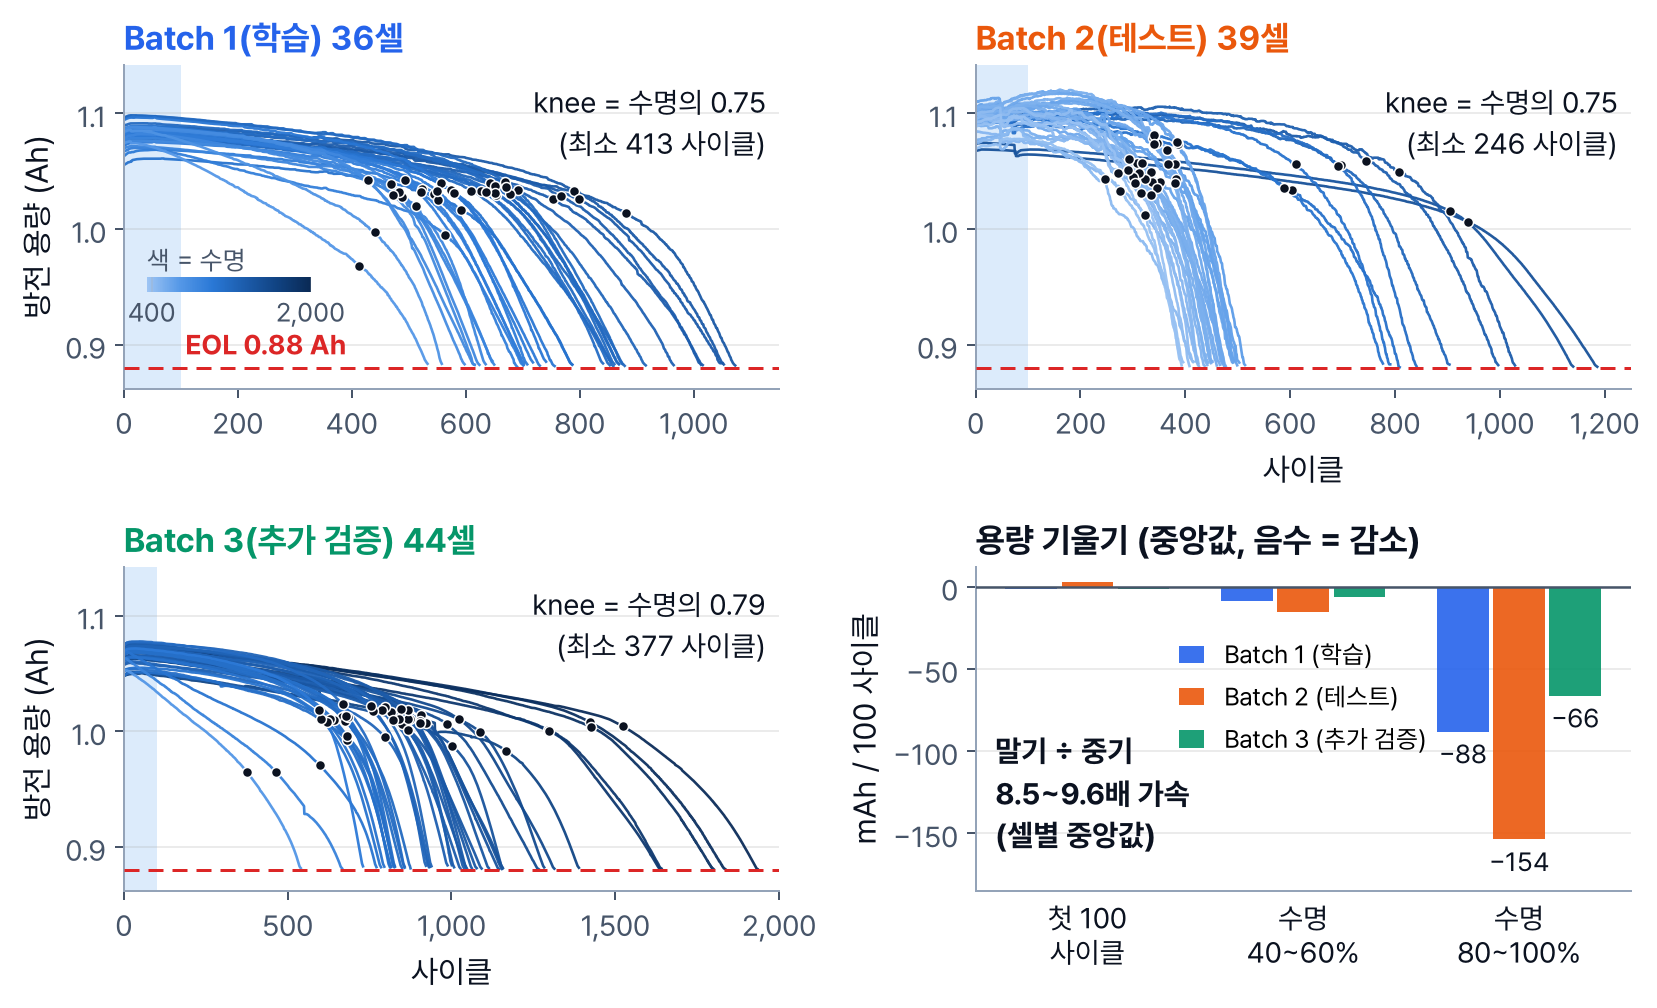

In [4]:
rows = []
for key in LAB["cell_key"]:
    c = by_key[key]
    life = float(c["cycle_life"])
    x, q, qs = q2.qd_series(c, upto=life)              # 사이클, 용량, 평활 용량
    knee = q2.bacon_watts_knee(x, qs)["knee"]           # 두 직선 적합의 꺾임점
    q_init, q_end = np.nanmedian(q[:5]), qs[-1]          # cycle 2~6 중앙값, EOL 직전
    d100 = q2.qd_at(c, 100) - q2.qd_at(c, 10)           # cycle 10 → 100 용량 변화 (Ah, + = 증가)
    rows.append({"batch": c["batch"], "knee": knee, "knee_ratio": knee / life,
                 "first100": -d100 / (q_init - q_end) * 100, "rose": d100 > 0})
K = pd.DataFrame(rows)

q2_table = K.groupby("batch").agg(셀=("knee", "size"), a=("knee", "median"), b=("knee", "min"),
                                  c=("knee_ratio", "median"), d=("first100", "median"), e=("rose", "sum"))
q2_table.columns = ["셀", "knee 중앙값", "knee 최소", "knee/수명 (중앙값)", "첫 100 사이클 손실 비중 % (중앙값)",
                    "cycle 10→100 용량이 늘어난 셀"]
display(q2_table.round(2))
print(f"knee가 첫 100 사이클 안에 있는 셀: {(K['knee'] <= 100).sum()} / {len(K)}")
show("slide_q2.png")

**결과**
- 거의 모든 셀이 '살짝 상승 → 완만한 감소 → 급락' 순서로 변한다(왼쪽 그림).
- 급락 시작점(knee)은 대체로 수명의 약 3/4 지점이다. 가장 이른 knee도 246 사이클이다.
- knee가 첫 100 사이클 안에 있는 셀은 하나도 없다.
- 첫 100 사이클 동안 줄어든 용량은 전체 손실의 1%도 안 된다.
- 수명 말기의 용량 감소 속도는 중기의 약 9배(8.5\~9.6배)다(오른쪽 그림).

**해석·시사점**
- 100 사이클 시점의 용량은 거의 새것 그대로다(SOH ≈ 100%). 용량 숫자만으로는 수명을 알 수 없다.
- 그래서 용량의 '크기' 대신 방전 곡선의 '모양 변화'(Q3의 ΔQ(V))에서 신호를 찾는다.
- knee는 미래 정보다. 피처에 들어가면 누수다 → 피처 코드에 **'사용 사이클 ≤ 100' 검사**를 넣었다(02 노트북).
- 곡선들은 시간 축만 늘이고 줄인 닮은꼴이다(knee/수명 비가 비슷). 배율 구조이므로 **log10 타깃**이 맞다.
- Batch 2는 cycle 10→100 사이에 용량이 오히려 늘어난 셀이 많다. 같은 ΔQ 창이 배치마다 다른 단계를 잴 수 있다는 위험으로 기록했다(DAY 1 보고서 §3 Q2 위험, §11 가설 H1의 break-in 원인 후보).

---
## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

**질문**
- 사이클 100과 사이클 10의 방전 곡선 차이, ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)는 어떻게 생겼는가?
- 장수명 셀과 단수명 셀은 ΔQ의 '모양'이 다른가, '깊이'가 다른가?
- 이 차이를 숫자 하나로 요약할 수 있는가?

**방법**
- `src/data.py`의 `delta_q`로 Batch 1 36셀의 ΔQ(V)를 1,000개 전압점에서 계산한다.
- 곡선이 가장 깊게 파인 전압을 찾는다.
- 깊이를 **ΔQ 깊이(dQ_logvar)** = log10(ΔQ의 분산) 하나로 요약한다(원논문 정의). 그리고 log10 수명과의 상관을 본다.

In [5]:
F = pd.read_csv("results/features.csv")              # src/features.py 산출물 (셀당 1행)
B1 = F[(F["batch"] == "batch1") & F["labeled"]].copy()
V = by_key["batch1-05"]["Vdlin"]                      # 전압 격자 3.5 → 2.0 V (모든 셀 동일)

v_at_min = [V[np.nanargmin(delta_q(by_key[k]))] for k in B1["cell_key"]]
r, _ = stats.pearsonr(B1["dQ_logvar"], np.log10(B1["cycle_life"]))
rho, _ = stats.spearmanr(B1["dQ_logvar"], B1["cycle_life"])
pd.DataFrame({"Batch 1 (36셀)": [np.median(v_at_min), r, r ** 2, rho]},
             index=["ΔQ가 가장 깊은 전압 (중앙값, V)", "Pearson r: ΔQ 깊이 vs log10 수명",
                    "r² (수명 분산 중 설명 비율)", "Spearman ρ"]).round(3)

,Batch 1 (36셀)
"ΔQ가 가장 깊은 전압 (중앙값, V)",2.935
Pearson r: ΔQ 깊이 vs log10 수명,-0.844
r² (수명 분산 중 설명 비율),0.712
Spearman ρ,-0.826


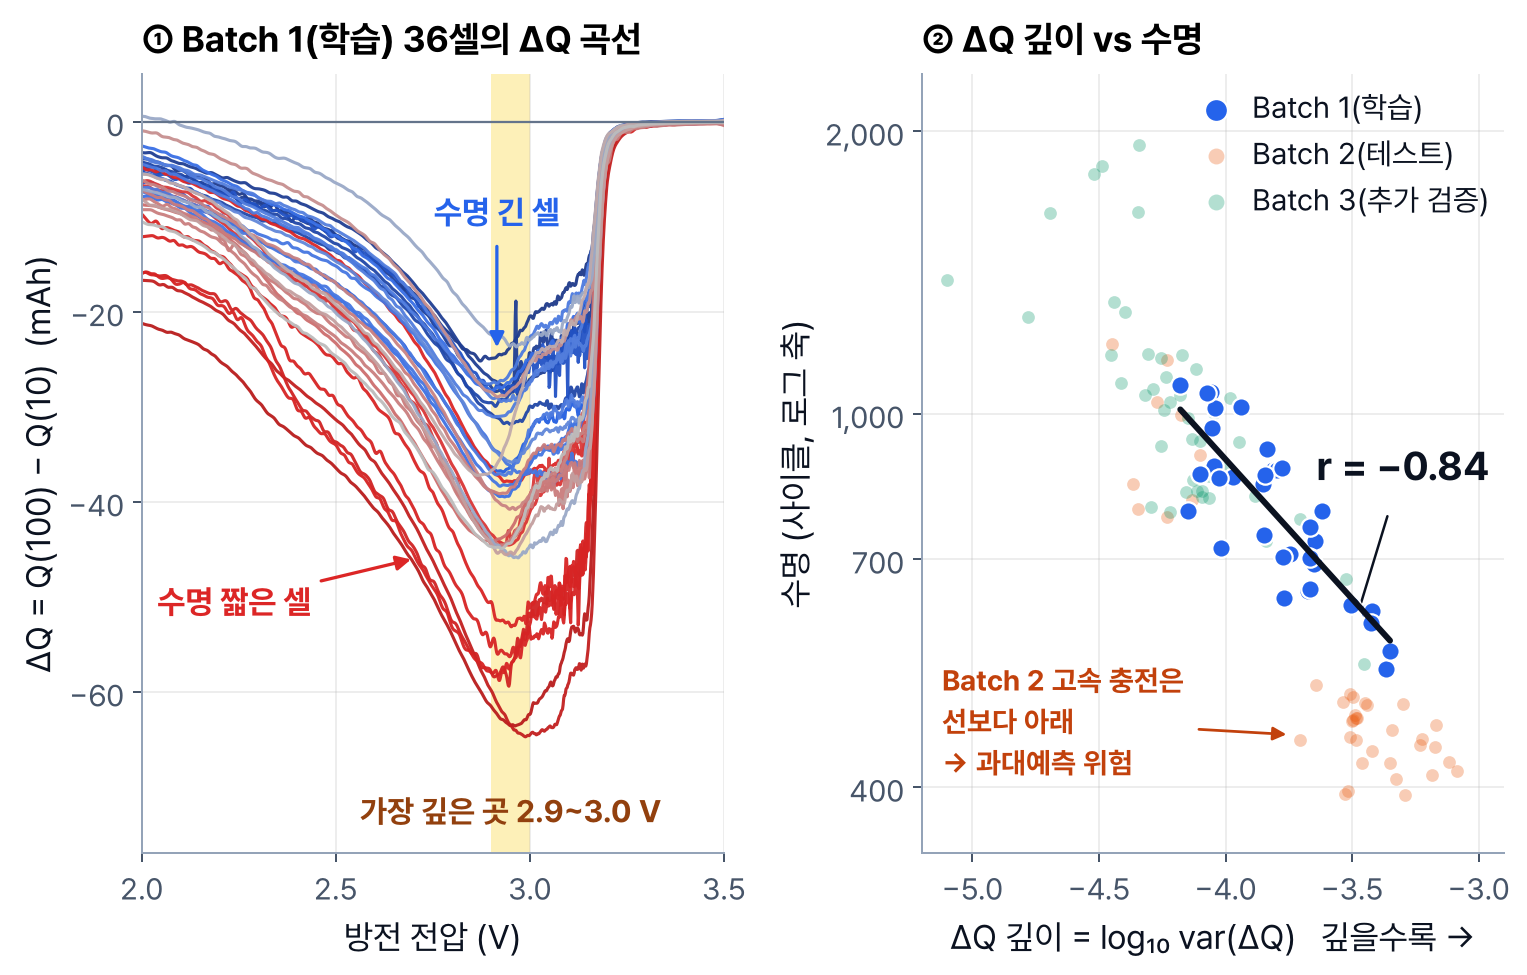

In [6]:
show("slide_q3.png")

**결과**
- 모든 셀에서 ΔQ는 음수이고, 가장 깊은 곳은 2.9\~3.0 V 부근이다.
- 수명이 짧은 셀일수록 같은 모양으로 더 깊게 파인다. 모양 자체는 거의 같다(왼쪽 그림).
- ΔQ 깊이 하나가 Batch 1 log10 수명 분산의 약 71%를 설명한다.

**해석·시사점**
- 용량이 1%도 안 줄어든 시점에, 곡선 안쪽에는 수명 차이가 이미 보인다.
- 정보는 '깊이' 하나에 모여 있다. 곡선 전체(1,000점) 대신 **스칼라 피처 하나(ΔQ 깊이)** 로 압축한다. 학습 셀이 36개뿐이라 이 편이 안전하다.
- 깊이와 수명은 로그–로그 직선 관계다 → **log10 타깃 + 선형 모델**과 잘 맞는다.
- 오른쪽 그림에서 Batch 2 고속충전 셀은 Batch 1 직선보다 아래에 있다. 같은 깊이인데 수명이 짧다. Batch 2를 **길게 예측(과대예측)** 할 위험으로 테스트 전에 기록했다.
- 주의: Batch 1에서 이 신호는 주로 '충전 정책 사이'의 차이를 반영한다. 같은 정책 복제셀끼리는 잘 가르지 못한다(Q5에서 보완).

---
## Q4. 충전 조건(C-rate)과 수명의 관계는?

**질문**
- 충전 프로토콜(정책)별 평균 수명은 얼마나 다른가?
- 고속 충전 셀이 정말 수명이 짧은가?

**방법**
- `src/data.py`의 `parse_policy`가 정책 문자열(예: 5.4C(40%)-3.6C)에서 0→80% 충전시간(t80)을 계산한다.
- '고속 충전'을 t80 ≤ 10분으로 정의하고, 두 그룹의 수명을 비교한다.
- 정책이 수명 차이를 얼마나 설명하는지 효과크기 ω²로 잰다(1에 가까울수록 정책이 대부분을 설명).

,셀,평균_수명,최소,최대
충전,,,,
고속 (t80 ≤ 10분),12,739.2,534.0,876.0
보통 (t80 > 10분),24,813.0,599.0,1074.0


고속 vs 보통 수명 차이: Mann–Whitney p = 0.29
정책 20개가 설명하는 수명 분산 ω² = 0.76


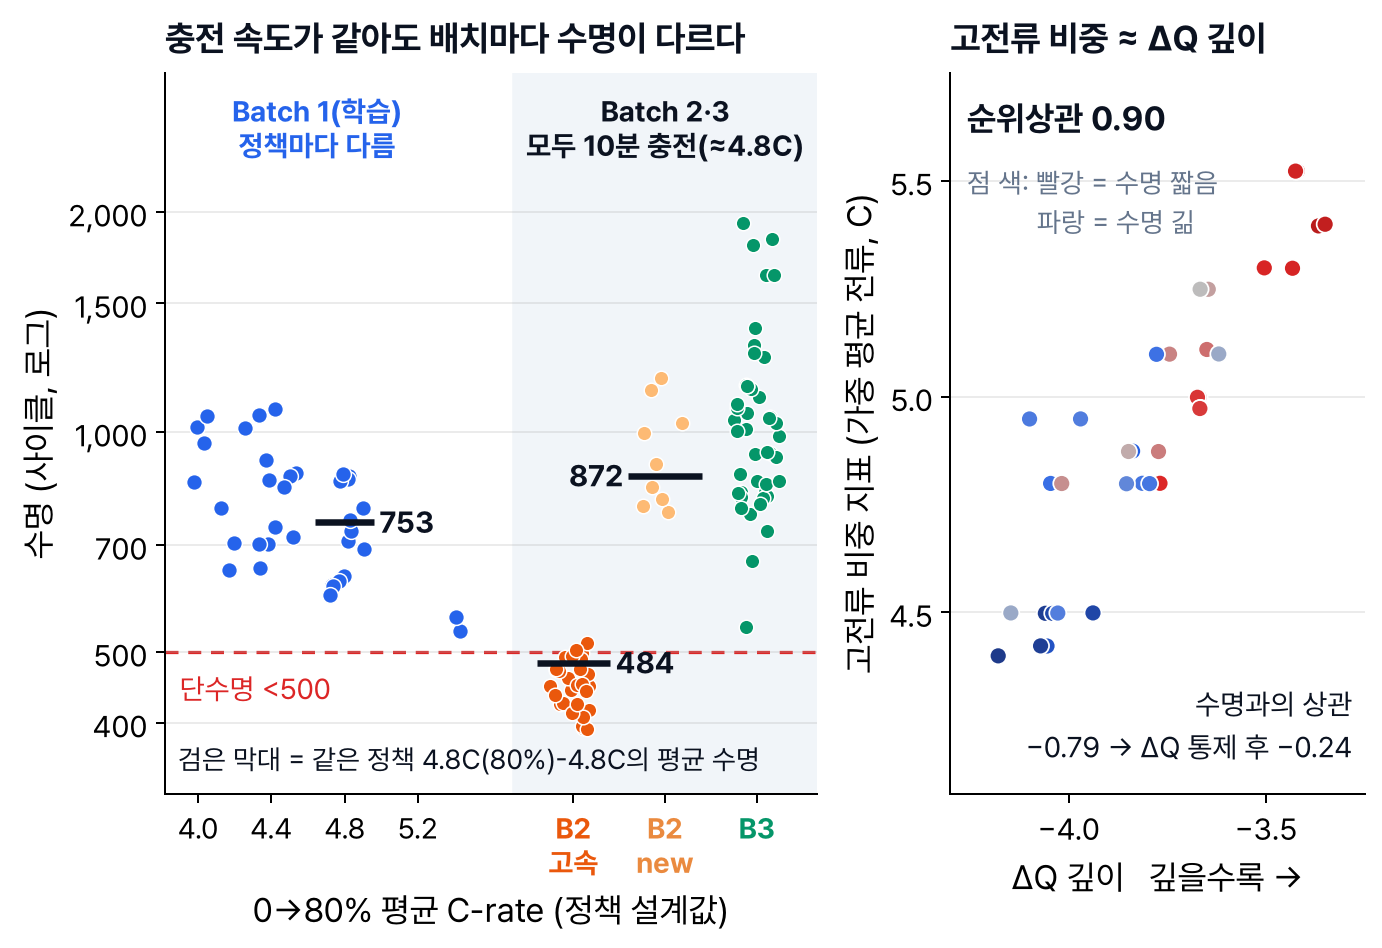

In [7]:
b1 = LAB[LAB["batch"] == "batch1"].copy()
b1["충전"] = np.where(b1["t80_min"] <= 10, "고속 (t80 ≤ 10분)", "보통 (t80 > 10분)")
speed = b1.groupby("충전")["cycle_life"].agg(셀="size", 평균_수명="mean", 최소="min", 최대="max")
p_speed = stats.mannwhitneyu(*[g["cycle_life"] for _, g in b1.groupby("충전")]).pvalue

# 정책 단위 일원분산분석 효과크기 ω² (수명 분산 중 정책이 설명하는 몫)
groups = [g["cycle_life"].to_numpy() for _, g in b1.groupby("policy")]
grand = b1["cycle_life"].mean()
ss_b = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
ss_w = sum(((g - g.mean()) ** 2).sum() for g in groups)
ms_w = ss_w / (len(b1) - len(groups))
omega2 = (ss_b - (len(groups) - 1) * ms_w) / (ss_b + ss_w + ms_w)

display(speed.round(1))
print(f"고속 vs 보통 수명 차이: Mann–Whitney p = {p_speed:.2f}")
print(f"정책 {len(groups)}개가 설명하는 수명 분산 ω² = {omega2:.2f}")
show("slide_q4.png")

**결과**
- Batch 1에는 단수명(<500) 셀이 없다. 가장 짧은 셀도 534 사이클이다.
- 고속 충전 셀의 평균 수명은 보통 셀보다 약간 짧지만, 통계적으로 구분되지 않는다.
- 대신 '어떤 정책이냐'가 수명 차이의 대부분을 설명한다(ω² 0.76).
- 충전량 중 고전류 비중이 클수록 수명이 짧은 경향은 있다. 그러나 이 신호는 ΔQ 깊이와 거의 겹친다(오른쪽 그림, 순위상관 0.90).

**해석·시사점**
- Batch 1에서는 고속 충전 셀이 뚜렷하게 짧지 않았다(p = 0.29, 12셀 vs 24셀). 셀이 적어 '효과가 없다'는 증거는 아니다.
- 충전 정책은 예측 시점에 알 수 있는 정보라, 피처로 쓰는 것 자체가 누수는 아니다.
- 누수는 분할에서 생긴다. 같은 정책 셀이 학습과 검증에 나뉘면 '정책 평균 수명'이 새어 들어간다.
  - → 검증 분할은 **정책 단위**로 한다.
- 충전 조건(정책명·C-rate·t80)을 피처로 쓰지 않는 이유는 따로 있다(Batch 1 근거).
  - 고전류 비중 신호는 ΔQ 깊이와 거의 겹쳐, 더하는 정보가 작다.
  - 같은 정책도 배치마다 수명이 달라(DAY 1 Q4) 배치를 넘어 통하지 않는다(위험 기록).
- ESS 관점: 이 데이터는 3.6\~8C 고속충전 실험이다.
  - 실제 ESS는 보통 1C 이하로 운전한다. 이 결과를 운전 전략 최적화에 바로 옮기면 안 된다.

---
## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

**질문**
- 초기 사이클 피처 중 수명과 가장 강하게 함께 움직이는 것은 무엇인가?
- 그 관계가 다른 배치에서도 유지되는가?
- ΔQ 깊이가 놓치는 정보를 다른 피처가 보완하는가?

**방법**
- DAY 1에 `src/eda/q5_correlation.py`로 초기 피처 19개의 배치별 Spearman 상관을 계산했다. 여기서는 저장 결과(`results/eda/q5_results.json`)를 읽어 Batch 1 상위 8개를 본다.
- Batch 2·3 상관은 '부호가 유지되는지' 확인하는 용도로만 본다(선택 근거 아님).
- ΔQ 깊이를 통제한 뒤 남는 정보는 `src/eda/q5d_conditional.py`의 결과(`q5d_results.json`)로 본다. 계산은 02 노트북에서 다시 한다.

,피처,Batch 1 ρ,Batch 2 ρ,Batch 3 ρ,배치 간 일관성
dQ_logvar,log₁₀ Var(ΔQ₁₀₀₋₁₀),-0.83,-0.71,-0.80,일관
dQ_logabsmin,log₁₀ |min ΔQ₁₀₀₋₁₀|,-0.79,-0.66,-0.78,일관
fade_slope_2_100,"용량 기울기 (2–100, −=감소)",0.47,-0.27,0.09,Batch 2: 부호 반전 / Batch 3: 약화/소멸
avgC_80,평균 C-rate (0→80%),-0.44,NaN,NaN,Batch 2: 상수(해석 불가) / Batch 3: 상수(해석 불가)
t80_min,0→80% 충전시간 (프로토콜),0.44,NaN,NaN,Batch 2: 상수(해석 불가) / Batch 3: 상수(해석 불가)
chargetime_avg5,평균 충전시간 (cycle 2–6),0.43,-0.80,0.21,Batch 2: 부호 반전 / Batch 3: 약화/소멸
dQ_skew,ΔQ₁₀₀₋₁₀ 왜도,-0.42,-0.15,0.06,Batch 2: 약화/소멸 / Batch 3: 약화/소멸
QD_max_minus_2,max QD − QD(2),0.36,-0.18,-0.18,Batch 2: 약화/소멸 / Batch 3: 약화/소멸


,단독 Spearman ρ,정책 평균끼리 상관 r,같은 정책 복제쌍에서 방향 일치
ΔQ 깊이 (dQ_logvar),-0.83,-0.88,8/16
초기 용량 (Qcc_init),0.15,0.04,14/16


초기 용량의 편상관 (ΔQ 깊이 통제): +0.68


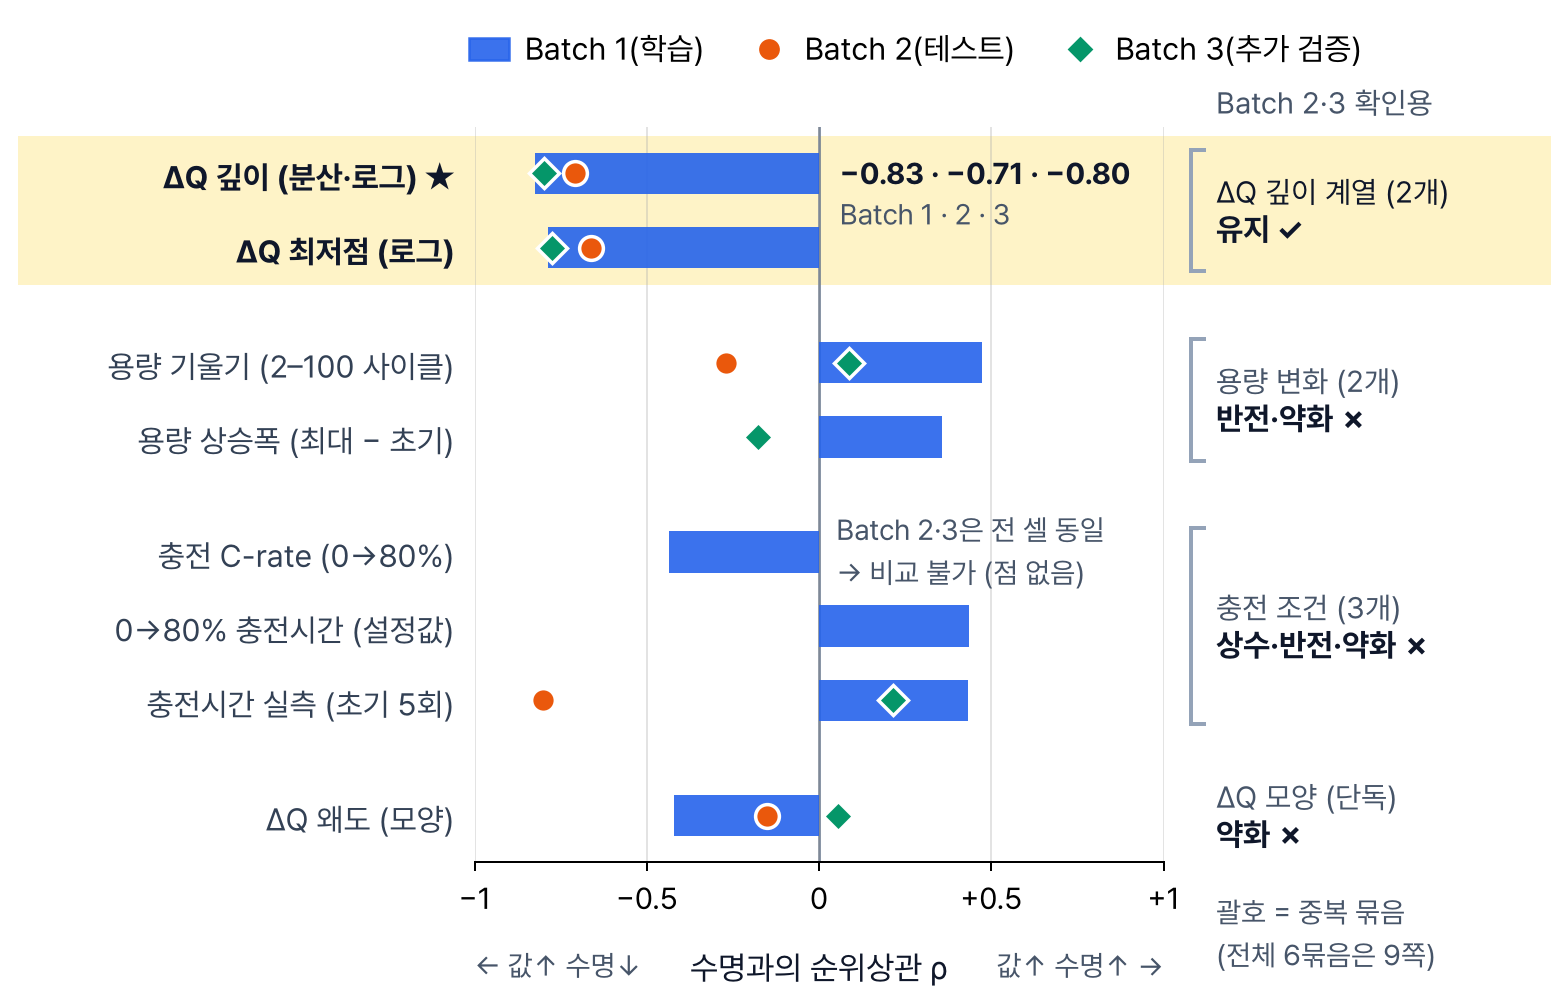

In [8]:
R5 = json.loads((EDA / "q5_results.json").read_text())
corr = R5["correlations"]
top = R5["batch1_rank_by_abs_spearman"][:8]
q5_table = pd.DataFrame({
    "피처": [q5.LBL[f] for f in top],
    "Batch 1 ρ": [corr["batch1"][f]["spearman"] for f in top],
    "Batch 2 ρ": [np.nan if corr["batch2"][f]["constant"] else corr["batch2"][f]["spearman"] for f in top],
    "Batch 3 ρ": [np.nan if corr["batch3"][f]["constant"] else corr["batch3"][f]["spearman"] for f in top],
    "배치 간 일관성": [R5["consistency_spearman"][f] for f in top]}, index=top)
display(q5_table.round(2))          # 빈 칸 = 그 배치에서 값이 사실상 상수라 상관을 해석할 수 없음

R5d = json.loads((EDA / "q5d_results.json").read_text())
pc, rp = R5d["partial_correlations"]["Qcc_init"], R5d["replicate_pairs"]
cond = pd.DataFrame({
    "단독 Spearman ρ": [corr["batch1"]["dQ_logvar"]["spearman"], pc["spearman_alone"]],
    "정책 평균끼리 상관 r": [rp["dQ_logvar"]["policy_mean_r"], rp["Qcc_init"]["policy_mean_r"]],
    "같은 정책 복제쌍에서 방향 일치": [f"{rp[k]['pairs_expected_direction']}/{rp[k]['n_pairs']}"
                                for k in ("dQ_logvar", "Qcc_init")]},
    index=["ΔQ 깊이 (dQ_logvar)", "초기 용량 (Qcc_init)"])
display(cond.round(2))
print(f"초기 용량의 편상관 (ΔQ 깊이 통제): {pc['partial_logvar']:+.2f}")
show("slide_q5.png")

**결과**
- Batch 1에서 확실히 강한 신호는 ΔQ 크기 계열 두 개뿐이다. 둘은 사실상 같은 정보다.
- Batch 1에서 그다음 순위인 용량 기울기·충전 조건·ΔQ 왜도는 ΔQ 깊이를 통제하면 유의하지 않다.
- Batch 2·3에서는 ΔQ 크기만 부호가 유지됐다. 나머지는 약해지거나 부호가 바뀐다(점검용, 선택 근거 아님).
- 두 번째 표: ΔQ 깊이는 **정책 사이**의 차이를, 초기 용량은 **같은 정책 복제셀 사이**의 차이를 설명한다.
- 초기 용량은 단독 상관은 약하지만, ΔQ 깊이를 통제하면 수명과 뚜렷하게 함께 움직인다(편상관 = ΔQ 깊이의 영향을 뺀 뒤 남는 상관).

**해석·시사점**
- 주 피처는 ΔQ 깊이 하나로 정한다(근거: Batch 1 순위상관 −0.83) → 기준 모델 **M0**(ΔQ 깊이만 쓰는 원논문 variance model).
- **초기 용량(Qcc_init)** 은 '후보'로 둔다 → 모델 **M1**(ΔQ 깊이 + 초기 용량). 채택 여부는 Batch 1 교차검증 규칙으로만 정한다.
- 서로 중복이 큰 피처는 그룹당 하나만 남긴다. 나머지는 축소 회귀(Elastic Net, **M2**)에서만 쓴다.

<details><summary>다중공선성 세부 (펼치기)</summary>

- 원논문 피처 조합을 그대로 쓰면 VIF가 수백까지 커진다(같은 양을 다른 방식으로 잰 피처가 많음).
- 그룹 대표만 남긴 M2 풀 10개는 VIF 5 미만이다. 02 노트북에서 다시 계산한다.
</details>

---
## 추가 확인 — 노션 경고 「Qdlin 변수를 단순 비교하면 왜곡 발생」

**질문**
- 노션은 "충전 커브 시작 시점이 배치별로 상이"하다고 경고한다. 우리 피처도 이 영향을 받는가?

**방법**
- 수명 라벨은 쓰지 않는다. 각 배치·그룹 **전체 셀**의 초기 용량 중앙값이 Batch 1에서 얼마나 이동했는지 잰다.
- ΔQ 깊이는 같은 셀의 두 사이클을 빼서 만들므로 배치 오프셋이 상쇄된다. 초기 용량은 절대 수준이라 상쇄되지 않는다.
- 이동량이 예측을 얼마나 바꿀지는 Batch 1 36셀의 기술적 적합 계수로 환산한다.

In [9]:
b1_qcc_all = F.loc[F["batch"] == "batch1", "Qcc_init"]
A = np.column_stack([np.ones(len(B1)), B1["dQ_logvar"], B1["Qcc_init"]])
coef_qcc = np.linalg.lstsq(A, np.log10(B1["cycle_life"]), rcond=None)[0][2]     # log10 수명 / Ah (Batch 1만)

rows = []
for (batch, group), g in F[F["group"].isin(["fastcharge", "newstructure"])].groupby(["batch", "group"]):
    shift = g["Qcc_init"].median() - b1_qcc_all.median()                      # 라벨 미사용 (전체 셀)
    rows.append({"배치 · 그룹": f"{batch} {group}", "셀 수 (전체)": len(g), "초기 용량 이동 (mAh)": shift * 1000,
                 "Batch 1 SD 단위": shift / B1["Qcc_init"].std(), "예측 배율로 환산": 10 ** (coef_qcc * shift)})
display(pd.DataFrame(rows).set_index("배치 · 그룹").round(2))
print(f"Batch 1 적합: 초기 용량 +10 mAh → 수명 ×{10 ** (coef_qcc * 0.010):.2f}")

,셀 수 (전체),초기 용량 이동 (mAh),Batch 1 SD 단위,예측 배율로 환산
배치 · 그룹,,,,
batch1 fastcharge,46,0.00,0.00,1.00
batch2 fastcharge,30,-5.32,-0.57,0.96
batch2 newstructure,9,-8.73,-0.94,0.94
batch3 newstructure,46,-14.52,-1.56,0.90


Batch 1 적합: 초기 용량 +10 mAh → 수명 ×1.08


**결과**
- 테스트 배치의 초기 용량 중앙값은 모두 Batch 1보다 낮다. Batch 3가 가장 많이 내려갔다.
- Batch 1 관계로 환산하면, 이 이동만으로 Batch 3 예측이 약 10% 낮아질 수 있다.

**해석·시사점**
- 초기 용량은 노션 경고에 그대로 해당하는 피처다. 그래서 DAY 2의 모든 성능 표에 **ΔQ 깊이만 쓰는 M0 행을 함께** 싣는다.
- 테스트 배치 통계로 피처의 중심을 다시 맞추는 보정은 하지 않는다. 테스트 정보가 모델에 새어 들어가기 때문이다.
- 이 이동량은 테스트 전에 기록했다. 03 노트북에서 실제 오차와 비교한다(가설 H6).

---
## 정리 — EDA에서 모델 설계로

| EDA 발견 | 모델 설계 결정 |
|---|---|
| Q1 학습 배치에 단수명 셀이 거의 없다 | 회귀, 타깃 = log10(cycle_life), 평가 = MAPE |
| Q1 Batch 1 중도절단 장수명 5셀(#00\~04)이 이미 학습 라벨·ΔQ 범위 밖이다 | 범위 밖으로도 예측이 이어지는 선형 모델 우선 (테스트 배치 범위 차이는 위험으로만 기록) |
| Q2 knee는 모두 100 사이클 이후다 | '사용 사이클 ≤ 100' 강제, knee는 피처 금지 |
| Q3 수명 정보가 ΔQ '깊이' 하나에 모인다 | 주 피처 = ΔQ 깊이(dQ_logvar), 기준 모델 M0 |
| Q4 정책이 수명 분산 대부분을 설명한다 | 정책 단위 Hold-out·교차검증, 충전 조건 피처 미사용 |
| Q5 초기 용량이 복제셀 차이를 보완한다 | 후보 피처 Qcc_init → M1, 채택은 사전 규칙으로만 |
| 노션 Qdlin 경고가 데이터에서 확인된다 | 모든 성능 표에 M0 행 병기 |

다음 노트북(02)에서 이 피처들을 실제로 계산하고 점검한다.